# Imports, loading data and exploring the baseline


In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# importing the cleaned data file (done in sql)
data_path = Path("C:/Users/Khush/Desktop/Supply Chain Project/supply-chain-delivery-optimizer/sql/data-1789208865909.csv")

df = pd.read_csv(data_path)

print(df.columns)

# Verify the view dataset loaded properly
print(f"Total Rows Loaded: {len(df):,}")
print("First 3 rows:")
print(df[["order_id", "shipping_mode", "market", "total_sales", "is_late"]].head(3))

print(" \n Target Variable Distribution (0 = On Time, 1 = Late):")
print(df["is_late"].value_counts(normalize=True))

Index(['order_id', 'order_item_id', 'customer_id', 'order_date',
       'shipping_date', 'shipping_mode', 'scheduled_days', 'actual_days',
       'delay_days', 'delivery_status', 'late_delivery_risk', 'is_late',
       'sla_met_flag', 'market', 'order_region', 'order_country', 'order_city',
       'category_name', 'product_name', 'quantity', 'product_price',
       'total_sales', 'profit', 'shipping_risk_tier'],
      dtype='object')
Total Rows Loaded: 180,519
First 3 rows:
   order_id   shipping_mode        market  total_sales  is_late
0     77202  Standard Class  Pacific Asia       327.75        0
1     75939  Standard Class  Pacific Asia       327.75        1
2     75938  Standard Class  Pacific Asia       327.75        0
 
 Target Variable Distribution (0 = On Time, 1 = Late):
is_late
1    0.548291
0    0.451709
Name: proportion, dtype: float64


# Data Visualisation (EDA)

Before transforming our variables for machine learning, we need to inspect the underlying distributions, identify potential class imbalances in our target (`is_late`), and understand how key supply chain features influence delivery delays.

## Analysing target class distribution

To check if 'is_late' is balanced or imbalanced

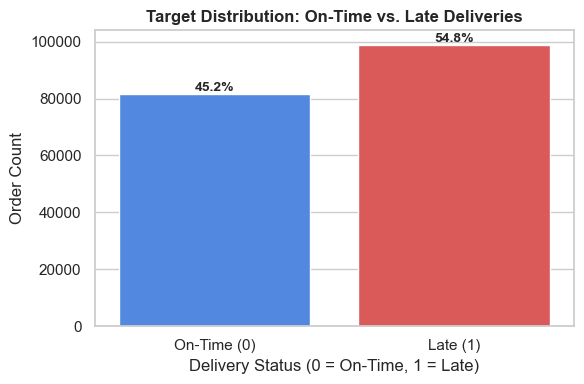

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# Bar chart of target variable
ax = sns.countplot(
    data=df,
    x="is_late",
    palette=["#3b82f6", "#ef4444"],
    hue="is_late",
    legend=False,
)

plt.title("Target Distribution: On-Time vs. Late Deliveries", fontsize=12, fontweight="bold")
plt.xlabel("Delivery Status (0 = On-Time, 1 = Late)")
plt.ylabel("Order Count")
plt.xticks(ticks=[0, 1], labels=["On-Time (0)", "Late (1)"])

# Add exact percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## Late Rate Breakdown by Shipping Mode & Market



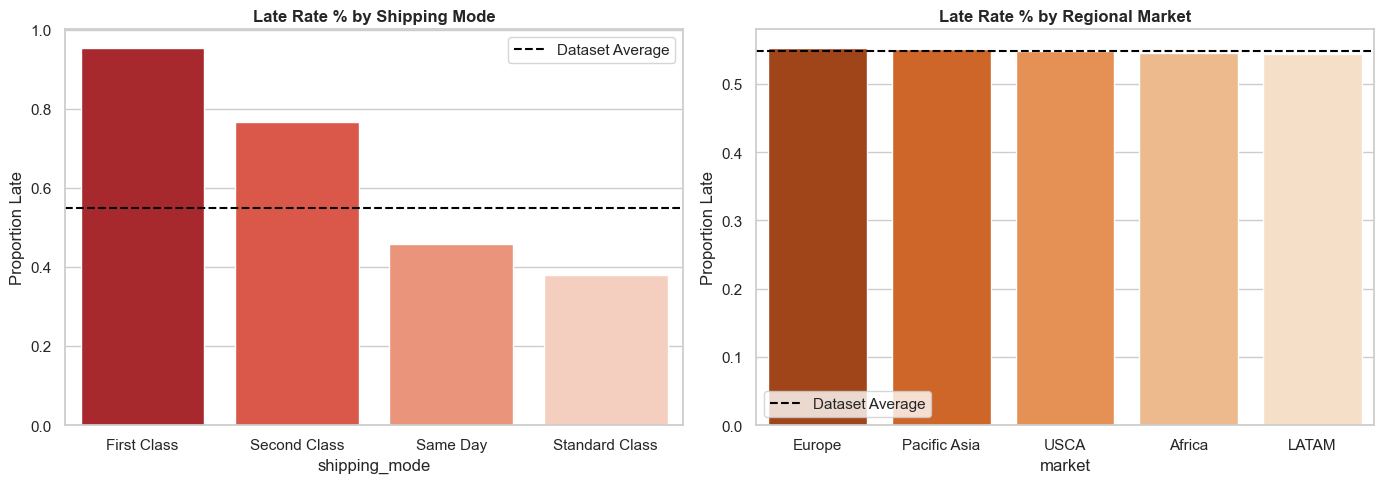

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Delay Rate by Shipping Mode
mode_risk = (
    df.groupby("shipping_mode")["is_late"]
    .mean()
    .reset_index()
    .sort_values(by="is_late", ascending=False)
)

sns.barplot(
    data=mode_risk,
    x="shipping_mode",
    y="is_late",
    ax=axes[0],
    palette="Reds_r",
    hue="shipping_mode",
    legend=False,
)
axes[0].axhline(df["is_late"].mean(), color="black", linestyle="--", label="Dataset Average")
axes[0].set_title("Late Rate % by Shipping Mode", fontweight="bold")
axes[0].set_ylabel("Proportion Late")
axes[0].legend()

# Plot 2: Delay Rate by Market
market_risk = (
    df.groupby("market")["is_late"]
    .mean()
    .reset_index()
    .sort_values(by="is_late", ascending=False)
)

sns.barplot(
    data=market_risk,
    x="market",
    y="is_late",
    ax=axes[1],
    palette="Oranges_r",
    hue="market",
    legend=False,
)
axes[1].axhline(df["is_late"].mean(), color="black", linestyle="--", label="Dataset Average")
axes[1].set_title("Late Rate % by Regional Market", fontweight="bold")
axes[1].set_ylabel("Proportion Late")
axes[1].legend()

plt.tight_layout()
plt.show()

## Scheduled Shipping Time vs. Delay Risk

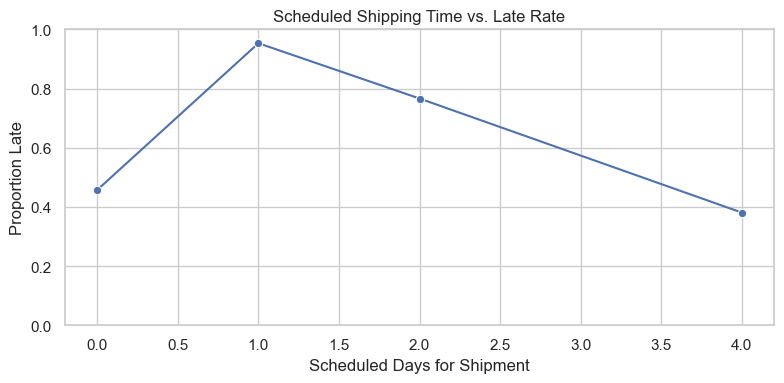

In [14]:
plt.figure(figsize=(8, 4))

# Scheduled Days vs Late Proportion
scheduled_risk = (
    df.groupby("scheduled_days")["is_late"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=scheduled_risk,
    x="scheduled_days",
    y="is_late",
    marker="o",
)

plt.title("Scheduled Shipping Time vs. Late Rate")
plt.xlabel("Scheduled Days for Shipment")
plt.ylabel("Proportion Late")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Key EDA Findings & Feature Hypotheses

Our data visualisation confirms the patterns previously identified in descriptive analysis using Power BI and provides a strong foundation for model feature selection:

1. **Target Class Balance:** 
   * The dataset target `is_late` is well-balanced (~55% late vs. ~45% on-time). No severe class imbalance techniques (e.g., SMOTE, class weighting) are required.

2. **Shipping Mode as a Dominant Feature:** 
   * **First Class** shipping demonstrates an extreme delay rate (>90%), whereas **Standard Class** exhibits significantly lower late rates (~38%). This variance makes `shipping_mode` a primary candidate for top feature importance in tree-based splits.

3. **Regional Market Stability:** 
   * Market regions (Europe, LATAM, Pacific Asia, USCA, Africa) display relatively uniform late rates near the global average. While included as a baseline feature, market alone may carry lower predictive weight compared to fulfillment parameters.

4. **Scheduled Delivery Window Impact:** 
   * A strong inverse correlation exists between promised lead times and delay rates: 1-day scheduled shipments suffer a ~90% failure rate, which gradually drops to ~40% as scheduled days increase to 4. 

---